# Agrupamiento espectral
## Star Wars II: Attack of the Clones

En esta notebook aplico el algoritmo del `00 Tutorial` a la red de coapariciones de *Attack of the Clones*.
La idea es usar la **Laplaciana**, el **vector de Fiedler** y el **ordenamiento espectral** para ver cómo se parte la red,
justificar hasta dónde conviene subdividirla y comparar el resultado con la actividad de **modularidad**.

In [1]:
import xml.etree.ElementTree as ET
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import display
from networkx.algorithms.community import greedy_modularity_communities

SEED = 863

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.options.display.max_colwidth = 200

La película se modela como una red de **coapariciones**. Si dos personajes comparten escena, existe una arista entre ellos.

En este caso la red es **conexa**, así que puedo empezar con toda la red y bisecarla con el vector de Fiedler.
Después reviso las subredes resultantes: si alguna sigue teniendo una conectividad algebraica baja, la vuelvo a dividir.

In [2]:
def get_display_labels(G):
    raw = nx.get_node_attributes(G, "label")
    return {node: raw.get(node, str(node)) for node in G.nodes()}


def rounded_list(values, digits=6):
    return [round(float(x), digits) for x in np.asarray(values, dtype=float)]


def communities_to_lookup(communities):
    lookup = {}
    for idx, community in enumerate(communities):
        for node in community:
            lookup[node] = idx
    return lookup


def algebraic_connectivity_safe(G, weight=None):
    if G.number_of_nodes() < 2 or not nx.is_connected(G):
        return 0.0
    return float(nx.algebraic_connectivity(G, weight=weight))


def spectral_report(G, labels, title, weight=None):
    print("=" * 100)
    print(title)
    print(f"nodos = {G.number_of_nodes()}, aristas = {G.number_of_edges()}, conexa = {nx.is_connected(G)}")
    spectrum = rounded_list(nx.laplacian_spectrum(G, weight=weight))
    print("laplacian_spectrum =", spectrum)
    result = {
        "title": title,
        "spectrum": spectrum,
        "groups": [set(G.nodes())],
        "lambda2": 0.0,
    }
    if not nx.is_connected(G):
        component_sizes = sorted([len(c) for c in nx.connected_components(G)], reverse=True)
        print("La subred no es conexa; antes de bisectar hay que separar componentes.")
        print("tamano_componentes =", component_sizes)
        return result
    lambda2 = algebraic_connectivity_safe(G, weight=weight)
    fiedler = nx.fiedler_vector(G, weight=weight)
    ordering = list(nx.spectral_ordering(G, weight=weight))
    groups = [set(part) for part in nx.spectral_bisection(G, weight=weight)]
    print(f"lambda_2 = {lambda2:.6f}")
    print("spectral_ordering =", [labels[node] for node in ordering])
    print("grupo_1 =", sorted(labels[node] for node in groups[0]))
    print("grupo_2 =", sorted(labels[node] for node in groups[1]))
    fiedler_df = (
        pd.DataFrame(
            {
                "nodo": [labels[node] for node in G.nodes()],
                "componente_fiedler": fiedler,
                "signo": np.where(fiedler >= 0, "+", "-"),
            }
        )
        .sort_values("componente_fiedler")
        .reset_index(drop=True)
    )
    display(fiedler_df.round(4))
    result.update(
        {
            "lambda2": lambda2,
            "ordering": ordering,
            "groups": groups,
            "fiedler_df": fiedler_df,
        }
    )
    return result


def partition_summary(G, communities, labels, weight=None):
    rows = []
    for idx, community in enumerate(sorted([set(c) for c in communities], key=len, reverse=True), start=1):
        SG = G.subgraph(community).copy()
        rows.append(
            {
                "grupo": idx,
                "nodos": len(community),
                "aristas_internas": SG.number_of_edges(),
                "densidad": round(nx.density(SG), 4) if len(community) > 1 else 0.0,
                "lambda_2": round(algebraic_connectivity_safe(SG, weight=weight), 4),
                "miembros": ", ".join(sorted(labels[node] for node in community)),
            }
        )
    return pd.DataFrame(rows)


def draw_partition(ax, G, communities, labels, title, pos=None):
    groups = [set(c) for c in communities]
    if pos is None:
        pos = nx.kamada_kawai_layout(G)
    lookup = communities_to_lookup(groups)
    node_colors = [lookup[node] for node in G.nodes()]
    node_sizes = [220 + 20 * G.degree(node) for node in G.nodes()]
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25, width=1.0, edge_color="#94a3b8")
    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_color=node_colors,
        node_size=node_sizes,
        cmap="nipy_spectral",
        linewidths=0.8,
        edgecolors="white",
    )
    font_size = 9 if G.number_of_nodes() <= 25 else 7
    nx.draw_networkx_labels(G, pos, ax=ax, labels=labels, font_size=font_size)
    ax.set_title(title)
    ax.axis("off")
    return pos


def plot_partition_sequence(G, labels, states, pos=None, ncols=2, figsize=(18, 12)):
    if pos is None:
        pos = nx.kamada_kawai_layout(G)
    nrows = int(np.ceil(len(states) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()
    for ax, state in zip(axes, states):
        draw_partition(ax, G, state["groups"], labels, state["title"], pos=pos)
    for ax in axes[len(states):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


def comparison_table(entries):
    return pd.DataFrame(entries).sort_values(["grafo", "Q"], ascending=[True, False]).reset_index(drop=True)

# `nx.read_gexf` falla con este archivo dinámico en NetworkX 3.6, así que hago un parser manual.
def read_dynamic_gexf_as_graph(fp):
    ns = {"g": "http://www.gexf.net/1.2draft"}
    root = ET.parse(fp).getroot()
    G = nx.Graph()
    for node in root.findall('.//g:node', ns):
        node_id = int(node.attrib["id"])
        G.add_node(node_id, label=node.attrib.get("label", str(node_id)))
    for edge in root.findall('.//g:edge', ns):
        u = int(edge.attrib["source"])
        v = int(edge.attrib["target"])
        weight = 1.0
        for attvalue in edge.findall('.//g:attvalue', ns):
            if attvalue.attrib.get("for") == "weight":
                weight = float(attvalue.attrib.get("value", 1.0))
        if G.has_edge(u, v):
            G[u][v]["weight"] += weight
        else:
            G.add_edge(u, v, weight=weight)
    return G

def find_project_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root()
folder = PROJECT_ROOT / "data/dataverse/gexf"
movie_id = 774
fp = folder / f"{movie_id}.gexf"

G_sw = read_dynamic_gexf_as_graph(fp)
labels_sw = get_display_labels(G_sw)
pos_sw = nx.kamada_kawai_layout(G_sw)

resumen_sw = pd.DataFrame(
    [
        {
            "nodos": G_sw.number_of_nodes(),
            "aristas": G_sw.number_of_edges(),
            "densidad": round(nx.density(G_sw), 4),
            "grado_medio": round(np.mean([grado for _, grado in G_sw.degree()]), 4),
            "es_conexa": nx.is_connected(G_sw),
        }
    ]
)

display(resumen_sw)

,nodos,aristas,densidad,grado_medio,es_conexa
0,47,148,0.1369,6.2979,True


## 1. Primera particion

In [3]:
root_sw = spectral_report(G_sw, labels_sw, "Paso 1. Red completa de coapariciones", weight="weight")

Paso 1. Red completa de coapariciones
nodos = 47, aristas = 148, conexa = True
laplacian_spectrum = [0.0, 0.911418, 0.944666, 1.0, 1.0, 1.0, 1.063891, 1.531029, 1.841322, 1.958629, 2.0, 2.0, 2.020357, 2.178905, 2.30489, 2.748596, 3.0, 3.0, 3.093237, 3.557152, 3.702999, 4.0, 4.01698, 4.49423, 4.707297, 5.263098, 5.981054, 6.253796, 6.714378, 7.608731, 8.0, 8.205481, 8.693087, 8.832263, 9.894871, 10.339655, 11.0, 11.214526, 12.24788, 13.447782, 16.862082, 19.251971, 21.705113, 32.940109, 38.887711, 63.756535, 78.824279]


lambda_2 = 0.911418
spectral_ordering = ['JOCASTA NU', 'PK-4', 'HERMIONE BAGWA', 'DEXTER JETTSTER', 'JANGO', 'BOBA FETT', 'TAUN WE', 'JANGO FETT', 'LAMA SU', 'DOOKU', 'WATTO', 'SHMI', 'ELAN', 'ZAM WESSEL', 'OBI-WAN', 'CHILDREN', 'DORME', 'WINDU', 'MACE', 'CAPTAIN TYPHO', 'JAR JAR', 'ANAKIN', 'MAS AMEDDA', 'SENATOR ASK AAK', 'BAIL ORGANA', 'AMIDALA', 'ORN FREE TAA', 'PALPATINE', 'RUWEE', 'QUEEN JAMILLIA', 'SIO BIBBLE', 'RYOO & POOJA', 'SOLA', 'JOBAL', 'CLIEGG', 'OWEN', 'BERU', 'KI-ADI-MUNDI', 'YODA', 'PADMÉ', 'THREEPIO', 'MACE WINDU', 'POGGLE', 'SUN RIT', 'NUTE GUNRAY', 'COUNT DOOKU', 'DARTH SIDIOUS']
grupo_1 = ['AMIDALA', 'ANAKIN', 'BAIL ORGANA', 'BOBA FETT', 'CAPTAIN TYPHO', 'CHILDREN', 'DEXTER JETTSTER', 'DOOKU', 'DORME', 'ELAN', 'HERMIONE BAGWA', 'JANGO', 'JANGO FETT', 'JAR JAR', 'JOCASTA NU', 'LAMA SU', 'MACE', 'MAS AMEDDA', 'OBI-WAN', 'ORN FREE TAA', 'PK-4', 'SENATOR ASK AAK', 'SHMI', 'TAUN WE', 'WATTO', 'WINDU', 'ZAM WESSEL']
grupo_2 = ['BERU', 'CLIEGG', 'COUNT DOOKU', 'DARTH SID

,nodo,componente_fiedler,signo
0,PK-4,-0.2001,-
1,JOCASTA NU,-0.2001,-
2,HERMIONE BAGWA,-0.2001,-
3,DEXTER JETTSTER,-0.2001,-
4,JANGO,-0.0323,-
5,BOBA FETT,-0.0309,-
6,TAUN WE,-0.0258,-
7,JANGO FETT,-0.0252,-
8,LAMA SU,-0.0237,-
9,DOOKU,-0.0198,-


**Interpretacion del primer corte**

- El primer eigenvalor positivo es $\lambda_2 pprox 0.911$, no tan pequeno como en una red casi desconectada, pero si lo bastante bajo para sugerir un **eje de separacion global**.
- Los valores mas negativos del vector de Fiedler caen en `PK-4`, `JOCASTA NU`, `DEXTER JETTSTER`, `HERMIONE BAGWA`, `JANGO FETT`, `TAUN WE` y el frente de investigacion de `OBI-WAN`. Ese extremo recoge la persecucion inicial, Kamino y los cazadores de recompensas.
- El extremo positivo esta dominado por `DARTH SIDIOUS`, `COUNT DOOKU`, `NUTE GUNRAY`, `POGGLE`, `SUN RIT`, junto con `PADME`, `YODA`, `PALPATINE` y el bloque familiar de Naboo/Tatooine. Ahí el algoritmo esta viendo el otro polo de la historia: la trama politica y la guerra que se esta cocinando.
- El ordenamiento espectral muestra una transicion bastante continua desde los personajes periféricos de la investigacion hasta el nucleo politico-separatista. Eso confirma que el primer corte no separa subtramas puras, sino una **polarizacion estructural** de toda la pelicula.

## 2. Subdivisiones recursivas

In [4]:
root_groups_sw = sorted(root_sw["groups"], key=len, reverse=True)
G_sw_a = G_sw.subgraph(root_groups_sw[0]).copy()
G_sw_b = G_sw.subgraph(root_groups_sw[1]).copy()

report_sw_a = spectral_report(G_sw_a, labels_sw, "Paso 2A. Subred grande despues del primer corte", weight="weight")
report_sw_b = spectral_report(G_sw_b, labels_sw, "Paso 2B. Subred pequena despues del primer corte", weight="weight")

final_partition_sw = sorted(
    [set(part) for part in report_sw_a["groups"]] + [set(part) for part in report_sw_b["groups"]],
    key=len,
    reverse=True,
)

print("\nResumen de la particion final propuesta")
display(partition_summary(G_sw, final_partition_sw, labels_sw, weight="weight"))

Paso 2A. Subred grande despues del primer corte
nodos = 27, aristas = 52, conexa = True
laplacian_spectrum = [0.0, 0.697016, 0.909608, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.044031, 1.643581, 1.937369, 2.0, 2.491784, 3.0, 3.598405, 4.247461, 4.850185, 5.168984, 5.729862, 6.902277, 7.641548, 8.45941, 8.752268, 11.158853, 18.110758, 47.6566]
lambda_2 = 0.697016
spectral_ordering = ['SHMI', 'WATTO', 'AMIDALA', 'ORN FREE TAA', 'SENATOR ASK AAK', 'MAS AMEDDA', 'BAIL ORGANA', 'CHILDREN', 'WINDU', 'HERMIONE BAGWA', 'DEXTER JETTSTER', 'PK-4', 'MACE', 'JOCASTA NU', 'CAPTAIN TYPHO', 'JAR JAR', 'DORME', 'ZAM WESSEL', 'ELAN', 'ANAKIN', 'OBI-WAN', 'LAMA SU', 'TAUN WE', 'JANGO', 'BOBA FETT', 'JANGO FETT', 'DOOKU']
grupo_1 = ['AMIDALA', 'ANAKIN', 'BAIL ORGANA', 'CAPTAIN TYPHO', 'CHILDREN', 'DEXTER JETTSTER', 'DORME', 'ELAN', 'HERMIONE BAGWA', 'JAR JAR', 'JOCASTA NU', 'LAMA SU', 'MACE', 'MAS AMEDDA', 'OBI-WAN', 'ORN FREE TAA', 'PK-4', 'SENATOR ASK AAK', 'SHMI', 'WATTO', 'WINDU', 'ZAM WESSEL']
grupo_2 = ['BOB

,nodo,componente_fiedler,signo
0,WATTO,-0.1478,-
1,SHMI,-0.1478,-
2,AMIDALA,-0.0940,-
3,ORN FREE TAA,-0.0905,-
4,SENATOR ASK AAK,-0.0783,-
5,MAS AMEDDA,-0.0777,-
6,BAIL ORGANA,-0.0718,-
7,JOCASTA NU,-0.0648,-
8,HERMIONE BAGWA,-0.0648,-
9,DEXTER JETTSTER,-0.0648,-


Paso 2B. Subred pequena despues del primer corte
nodos = 20, aristas = 42, conexa = True
laplacian_spectrum = [-0.0, 0.88714, 1.0, 1.08974, 1.47609, 1.75886, 2.547441, 3.0, 3.0, 4.368841, 5.307037, 5.492505, 7.0, 8.119898, 8.345241, 8.838326, 9.0, 13.186108, 21.465858, 32.116915]
lambda_2 = 0.887140
spectral_ordering = ['RYOO & POOJA', 'QUEEN JAMILLIA', 'SIO BIBBLE', 'CLIEGG', 'THREEPIO', 'BERU', 'RUWEE', 'OWEN', 'JOBAL', 'SOLA', 'PADMÉ', 'PALPATINE', 'KI-ADI-MUNDI', 'MACE WINDU', 'YODA', 'POGGLE', 'SUN RIT', 'NUTE GUNRAY', 'COUNT DOOKU', 'DARTH SIDIOUS']
grupo_1 = ['BERU', 'CLIEGG', 'JOBAL', 'OWEN', 'PADMÉ', 'QUEEN JAMILLIA', 'RUWEE', 'RYOO & POOJA', 'SIO BIBBLE', 'SOLA', 'THREEPIO']
grupo_2 = ['COUNT DOOKU', 'DARTH SIDIOUS', 'KI-ADI-MUNDI', 'MACE WINDU', 'NUTE GUNRAY', 'PALPATINE', 'POGGLE', 'SUN RIT', 'YODA']


,nodo,componente_fiedler,signo
0,RYOO & POOJA,-0.2281,-
1,QUEEN JAMILLIA,-0.2280,-
2,SIO BIBBLE,-0.2280,-
3,THREEPIO,-0.0755,-
4,CLIEGG,-0.0755,-
5,BERU,-0.0727,-
6,RUWEE,-0.0638,-
7,OWEN,-0.0611,-
8,SOLA,-0.0546,-
9,JOBAL,-0.0546,-



Resumen de la particion final propuesta


,grupo,nodos,aristas_internas,densidad,lambda_2,miembros
0,1,22,40,0.1732,0.9080,"AMIDALA, ANAKIN, BAIL ORGANA, CAPTAIN TYPHO, CHILDREN, DEXTER JETTSTER, DORME, ELAN, HERMIONE BAGWA, JAR JAR, JOCASTA NU, LAMA SU, MACE, MAS AMEDDA, OBI-WAN, ORN FREE TAA, PK-4, SENATOR ASK AAK, S..."
1,2,11,19,0.3455,1.0000,"BERU, CLIEGG, JOBAL, OWEN, PADMÉ, QUEEN JAMILLIA, RUWEE, RYOO & POOJA, SIO BIBBLE, SOLA, THREEPIO"
2,3,9,15,0.4167,0.9011,"COUNT DOOKU, DARTH SIDIOUS, KI-ADI-MUNDI, MACE WINDU, NUTE GUNRAY, PALPATINE, POGGLE, SUN RIT, YODA"
3,4,5,7,0.7000,1.0540,"BOBA FETT, DOOKU, JANGO, JANGO FETT, TAUN WE"


**Interpretacion de las subdivisiones**

- La subred grande del primer corte todavia tiene $\lambda_2 pprox 0.697$, asi que si vale la pena volver a partirla. Al hacerlo, el algoritmo desprende un grupo muy claro de **Kamino/Jango**: `JANGO FETT`, `BOBA FETT`, `TAUN WE`, `JANGO` y `DOOKU`.
- La otra subred tiene $\lambda_2 pprox 0.887$ y aun permite una ultima biseccion interpretable. Ahí aparecen por un lado `PADME`, `BERU`, `OWEN`, `CLIEGG`, `JOBAL`, `SOLA`, `RUWEE`, `THREEPIO` y los personajes ligados a Naboo/Tatooine; por el otro, un bloque mas politico-militar con `PALPATINE`, `YODA`, `MACE WINDU`, `COUNT DOOKU`, `NUTE GUNRAY`, `POGGLE`, `SUN RIT` y `DARTH SIDIOUS`.
- Las cuatro hojas finales quedan con $\lambda_2$ alrededor de `0.90` o `1.00`, ya no cercanos a cero. Por eso **ahi me detengo**: se pueden forzar mas subdivisiones, pero ya no parecen cortes naturales sino separaciones cada vez mas finas dentro de grupos que ya son compactos.
- Desde la historia de *Attack of the Clones*, lo mas interesante es que el agrupamiento espectral recupera bastante bien tres frentes narrativos: **Kamino/Jango**, **Padme-Tatooine-Naboo** y **nucleo politico-separatista**. El cuarto bloque es mas hibrido porque mezcla la investigacion inicial, los puentes de `OBI-WAN` y personajes institucionales que aparecen en escenas de transicion.

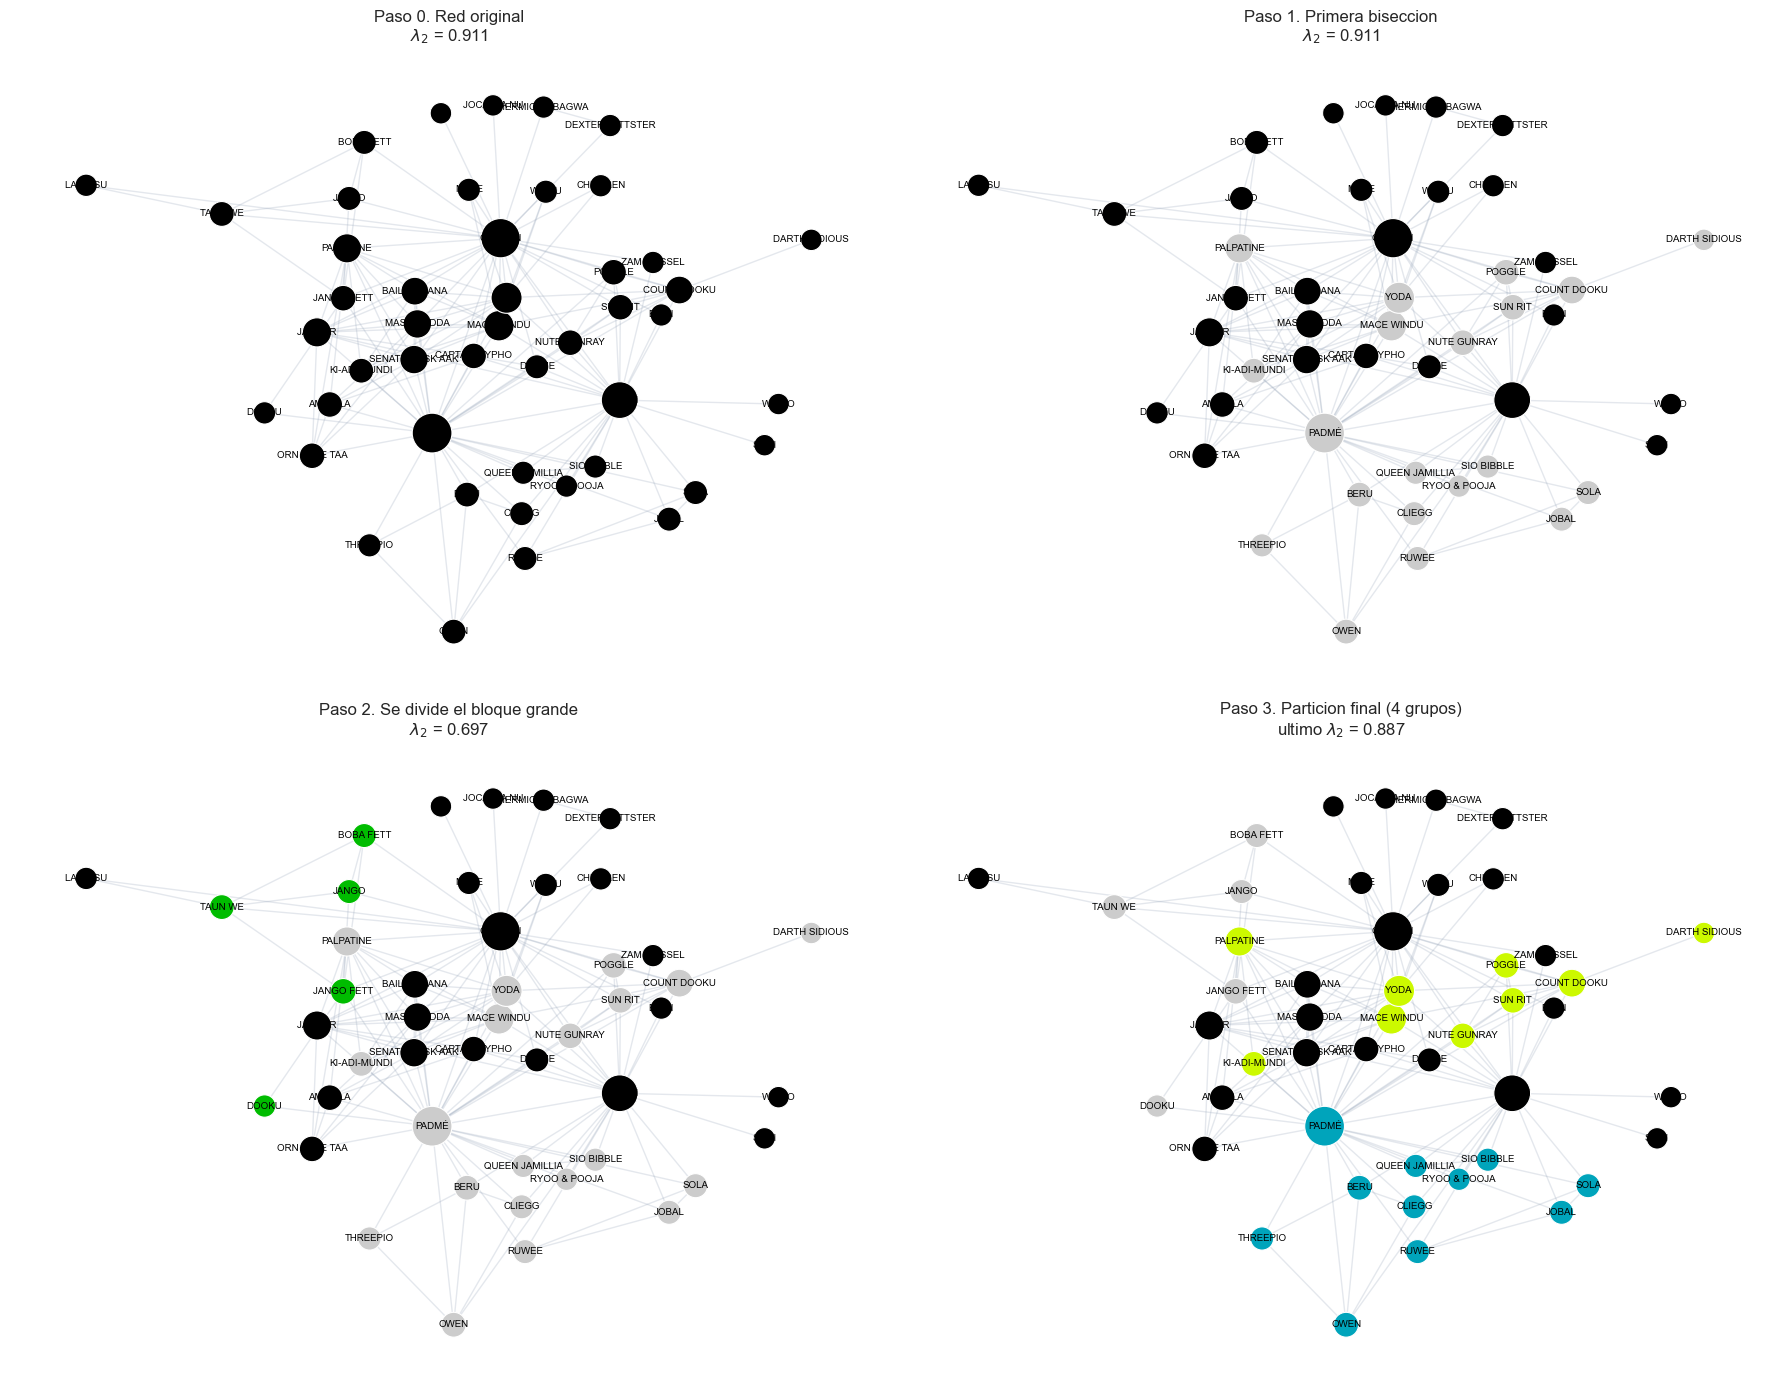

In [5]:
states_sw = [
    {
        "title": f"Paso 0. Red original\n$\lambda_2$ = {root_sw['lambda2']:.3f}",
        "groups": [set(G_sw.nodes())],
    },
    {
        "title": f"Paso 1. Primera biseccion\n$\lambda_2$ = {root_sw['lambda2']:.3f}",
        "groups": root_groups_sw,
    },
    {
        "title": f"Paso 2. Se divide el bloque grande\n$\lambda_2$ = {report_sw_a['lambda2']:.3f}",
        "groups": [set(part) for part in report_sw_a["groups"]] + [set(G_sw_b.nodes())],
    },
    {
        "title": f"Paso 3. Particion final (4 grupos)\nultimo $\lambda_2$ = {report_sw_b['lambda2']:.3f}",
        "groups": final_partition_sw,
    },
]

plot_partition_sequence(G_sw, labels_sw, states_sw, pos=pos_sw, ncols=2, figsize=(18, 14))

## 3. Comparacion con modularidad

En la actividad de modularidad aparecian **4 comunidades** tambien, pero con una logica diferente.
La modularidad premia grupos con muchas aristas internas y pocas externas; el agrupamiento espectral con Laplaciana,
en cambio, busca **cortes suaves** guiados por el vector de Fiedler.

,grafo,metodo,grupos,Q
0,Star Wars completo,greedy_modularity_communities,4,0.3339
1,Star Wars completo,espectral laplaciano recursivo,4,0.1901


,grupo,nodos,aristas_internas,densidad,lambda_2,miembros
0,1,16,36,0.3000,1.0000,"ANAKIN, BERU, CAPTAIN TYPHO, CLIEGG, DORME, JOBAL, OWEN, PADMÉ, QUEEN JAMILLIA, RUWEE, RYOO & POOJA, SHMI, SIO BIBBLE, SOLA, THREEPIO, WATTO"
1,2,15,41,0.3905,0.8029,"AMIDALA, BAIL ORGANA, CHILDREN, COUNT DOOKU, DARTH SIDIOUS, JAR JAR, KI-ADI-MUNDI, MACE, MACE WINDU, MAS AMEDDA, ORN FREE TAA, PALPATINE, SENATOR ASK AAK, WINDU, YODA"
2,3,13,20,0.2564,0.7411,"BOBA FETT, DEXTER JETTSTER, DOOKU, ELAN, HERMIONE BAGWA, JANGO, JANGO FETT, JOCASTA NU, LAMA SU, OBI-WAN, PK-4, TAUN WE, ZAM WESSEL"
3,4,3,3,1.0000,6.0000,"NUTE GUNRAY, POGGLE, SUN RIT"


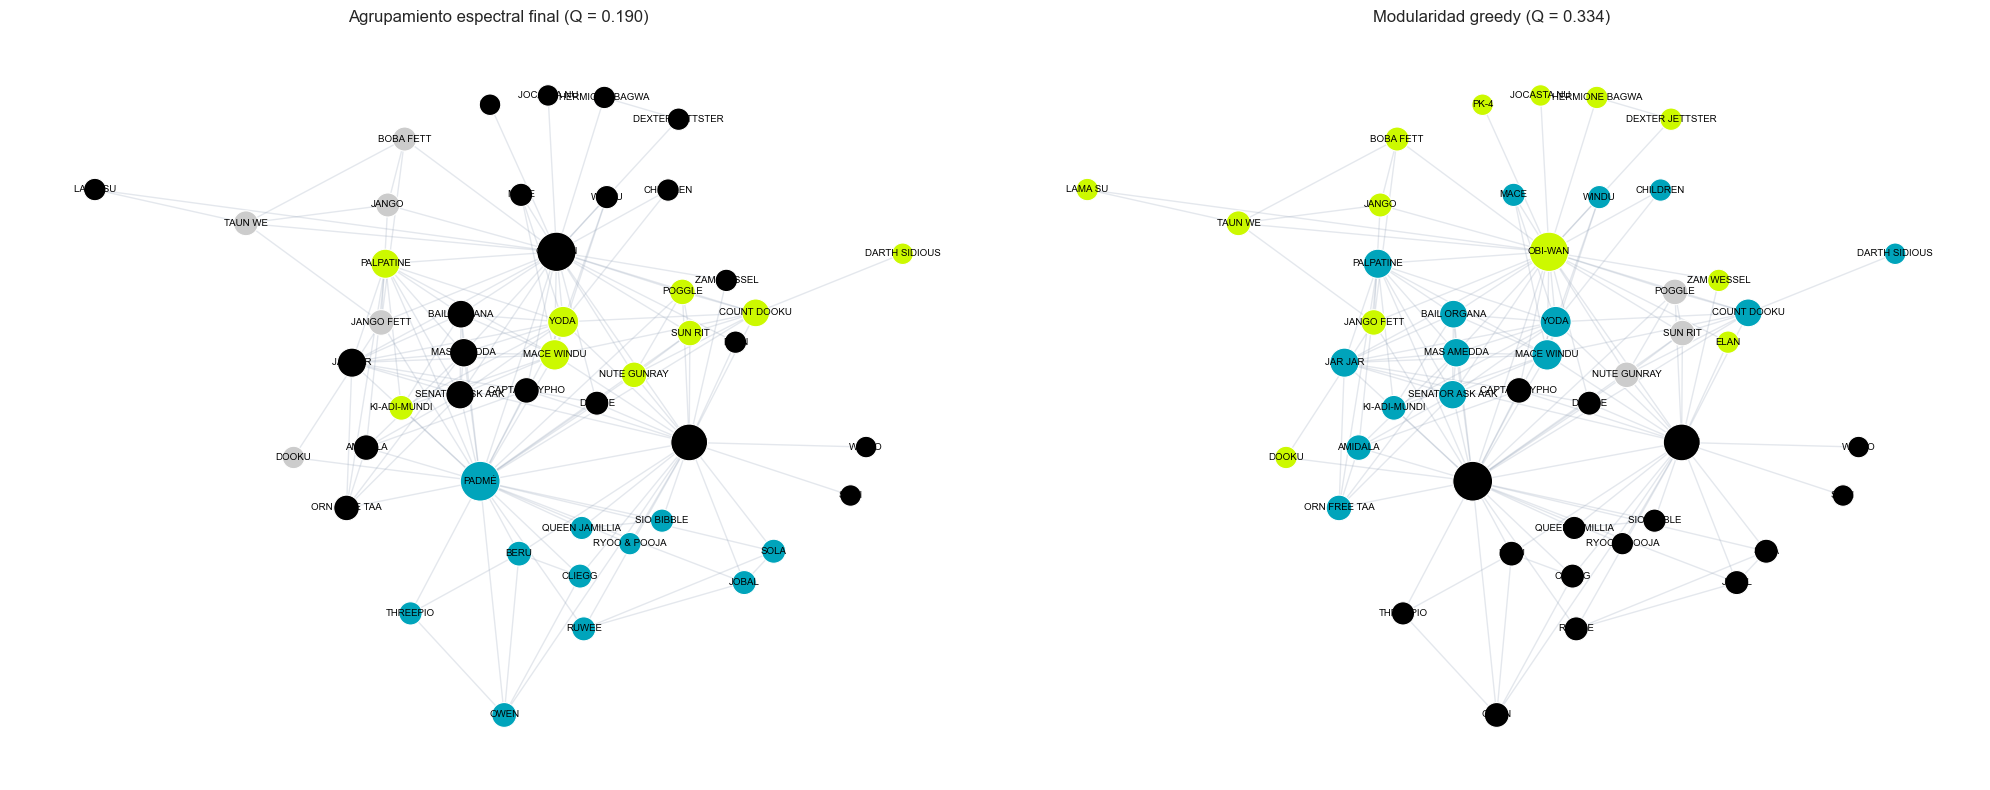

In [6]:
comunidades_mod_sw = sorted(list(greedy_modularity_communities(G_sw, weight="weight")), key=len, reverse=True)
q_spectral_sw = nx.algorithms.community.modularity(G_sw, final_partition_sw, weight="weight")
q_mod_sw = nx.algorithms.community.modularity(G_sw, comunidades_mod_sw, weight="weight")

comparacion_sw = comparison_table(
    [
        {
            "grafo": "Star Wars completo",
            "metodo": "greedy_modularity_communities",
            "grupos": len(comunidades_mod_sw),
            "Q": round(q_mod_sw, 4),
        },
        {
            "grafo": "Star Wars completo",
            "metodo": "espectral laplaciano recursivo",
            "grupos": len(final_partition_sw),
            "Q": round(q_spectral_sw, 4),
        },
    ]
)

display(comparacion_sw)
display(partition_summary(G_sw, comunidades_mod_sw, labels_sw, weight="weight"))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
draw_partition(
    axes[0],
    G_sw,
    final_partition_sw,
    labels_sw,
    title=f"Agrupamiento espectral final (Q = {q_spectral_sw:.3f})",
    pos=pos_sw,
)
draw_partition(
    axes[1],
    G_sw,
    comunidades_mod_sw,
    labels_sw,
    title=f"Modularidad greedy (Q = {q_mod_sw:.3f})",
    pos=pos_sw,
)
plt.tight_layout()
plt.show()

**Conclusion**

- Las agrupaciones espectrales **si tienen sentido**, sobre todo como lectura de los puentes estructurales de la pelicula. `DARTH SIDIOUS` queda como extremo de un polo porque casi toda su conectividad esta concentrada en el frente separatista; `OBI-WAN` y la investigacion de Kamino quedan del otro lado porque son quienes enlazan escenas de descubrimiento y persecucion.
- Si la pregunta es "¿que describe mejor las **subtramas**?", entonces **prefiero modularidad**: su particion tiene una $Q$ mas alta y separa mejor los bloques narrativos locales.
- Si la pregunta es "¿cual es la **fractura estructural global** de la red?", el agrupamiento espectral aporta algo muy util, porque deja ver como la pelicula se organiza entre el frente de investigacion/Kamino y el frente politico-militar que desemboca en Geonosis.
- En otras palabras: **modularidad gana para comunidades**, mientras que **Laplaciana gana para entender puentes y polarizacion global**.